# Comparação do Impacto do Data Augmentation

Avalia o impacto da aplicação de técnicas de aumento de dados (_data augmentation_) durante o treinamento.

**Configuração base (herdada do notebook anterior):**
- Normalização: `preprocess_input`
- Balanceamento de classes: desativado
- Learning rate: `0.001`
- Threshold de decisão: `0.5`

**Variável analisada:** aplicação de _data augmentation_ no conjunto de treinamento

| Experimento | Data augmentation |
|---|---|
| `*-baseline` | ativado — flip horizontal, rotação aleatória (±5%) e zoom aleatório (±10%) |
| `*-no-data-aug` | desativado |

O data augmentation tem como objetivo aumentar artificialmente a diversidade do conjunto de treinamento, reduzindo o risco de sobreajuste (_overfitting_) e melhorando a capacidade de generalização do modelo.

## Preparação do ambiente e carregamento dos experimentos

Clonagem do repositório do GitHub

In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
Cloning into 'classification-of-medical-images-using-cnn'...
remote: Enumerating objects: 1737, done.
remote: Counting objects: 100% (714/714), done.
remote: Compressing objects: 100% (506/506), done.
remote: Total 1737 (delta 275), reused 608 (delta 208), pack-reused 1023 (from 1)
Receiving objects: 100% (1737/1737), 12.51 MiB | 26.03 MiB/s, done.
Resolving deltas: 100% (793/793), done.
/content/classification-of-medical-images-using-cnn


Montagem do Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Mounted at /content/drive


Definição dos:
- Nomes dos experimentos analisados
- Caminho relativo do diretório onde as comparações serão salvas
- Caminho da pasta onde os resultados dos modelos estão salvos no Google Drive
- Caminho da pasta onde as comparações serão salvas no Google Drive

In [7]:
experiment_names = ["resnet-baseline", "resnet-no-data-aug",
                  "densenet-baseline", "densenet-no-data-aug",
                  "efficientnet-baseline", "efficientnet-no-data-aug"]
COMPARISON_PATH = "comparisons/02-data-aug"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

Carregamento dos experimentos

In [8]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)


## Visualização das métricas finais com média e desvio padrão

In [9]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
resnet-baseline,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
resnet-no-data-aug,0.808226,0.018704,0.768948,0.019748,0.992308,0.004187,0.866276,0.010908,0.501425,0.056730,0.963535,0.003811
densenet-baseline,0.855769,0.019275,0.831175,0.031108,0.968376,0.017433,0.893862,0.010904,0.668091,0.080355,0.956991,0.001435
densenet-no-data-aug,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
efficientnet-baseline,0.866987,0.022664,0.848382,0.044925,0.964103,0.025726,0.901138,0.013308,0.705128,0.102979,0.961047,0.002615
efficientnet-no-data-aug,0.796474,0.030095,0.756865,0.028928,0.996581,0.003198,0.859976,0.017490,0.462963,0.085494,0.968920,0.002772


- O modelo resnet-no-data-aug apresentou desvio padrão inferior em todas as métricas, com resultados médios superiores apenas em recall e AUC-ROC. No entanto o alto recall é reflexo da agressividade do modelo, que pode ser vista através de sua baixa especificidade média (próxima de 0.5).
- O modelo densenet-no-data-aug também apresentou recall e AUC-ROC médios superiores ao respectivo modelo baseline, também devido à sua agressividade (especificidade ≈ 0.54). Porém, quanto ao desvio padrão, houve um aumento em quase todas as métricas, com exceção do recall.
- Quanto ao modelo efficientnet-no-data-aug, a evolução de seu desempenho médio foi semelhante ao dos modelos descritos anteriormente, apresentando a maior agressividade dentre todos (recall ≈ 0.997 e especificidade ≈ 0.463). Quanto ao desvio padrão, ora se mostrou superior (acurácia, score F1, AUC-ROC), ora inferior (precisão, recall, especificidade) ao modelo baseline.

## Visualizaçãs dos gráficos dos experimentos com ResNet

- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos

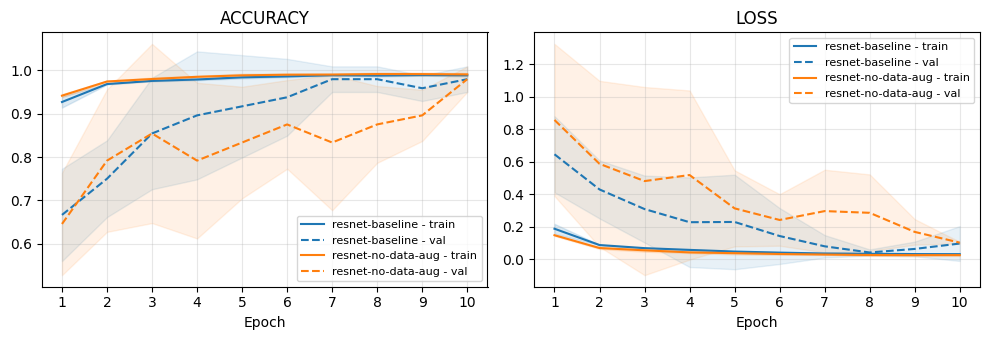

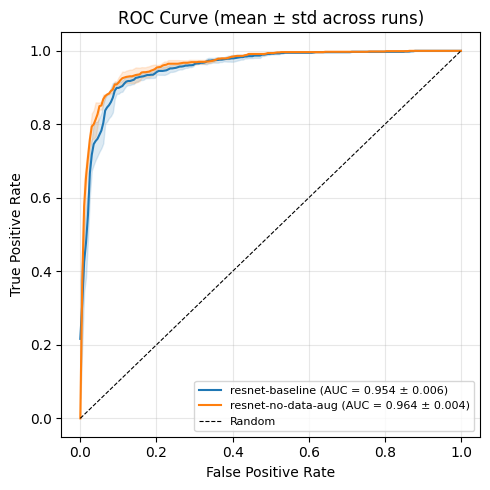

In [10]:
from src.analyses import plot_training_history
from src.analyses import plot_roc_curves
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig_history = plot_training_history(resnet_exps, metrics=["accuracy", "loss"])
fig_roc = plot_roc_curves(resnet_exps)

plt.show()

O modelo resnet-no-data-aug se mostrou mais instável durante a validação, com desvio padrão visivelmente superior para ambas métricas durante quase todas as épocas (com exceção da última).

## Visualizaçãs dos gráficos dos experimentos com DenseNet

- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos

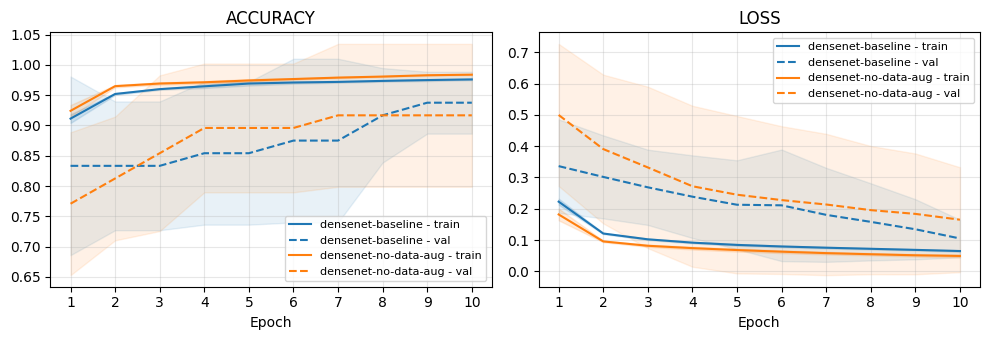

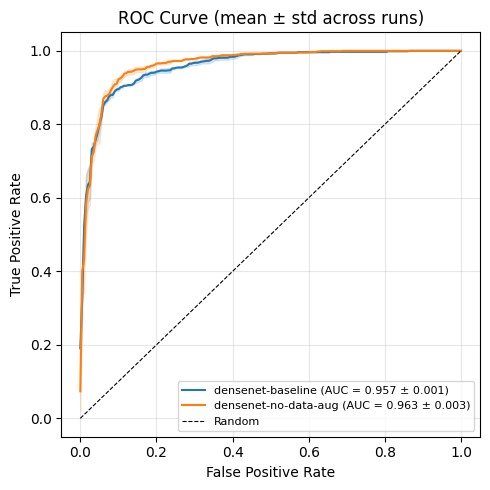

In [11]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig = plot_training_history(densenet_exps, metrics=["accuracy", "loss"])
fig = plot_roc_curves(densenet_exps)

plt.show()

O modelo densenet-no-data-aug se mostrou mais instável durante a validação, com desvio padrão visivelmente superior para ambas métricas durante quase todas as épocas (com exceção da última).

## Visualização dos gráficos dos experimentos com EfficientNet

- Visualização dos gráficos de treino/validação
- Visualização das curvas ROC dos experimentos

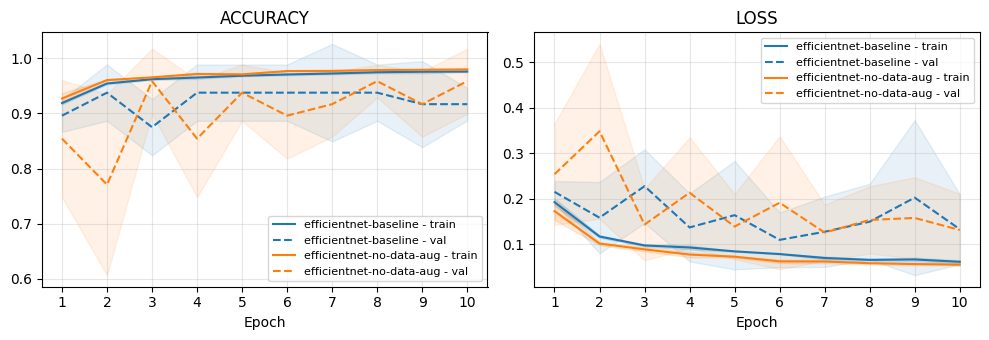

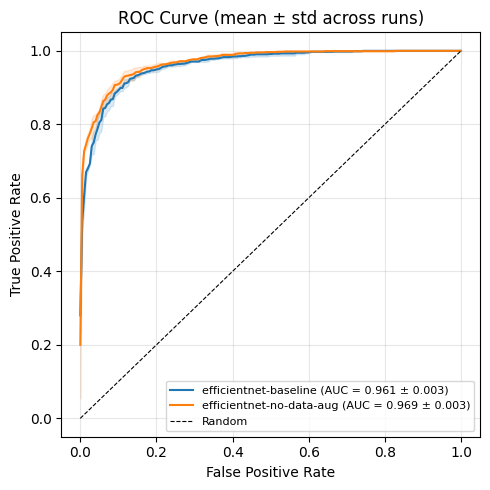

In [12]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig = plot_training_history(efficientnet_exps, metrics=["accuracy", "loss"])
fig = plot_roc_curves(efficientnet_exps)

plt.show()

O modelo efficientnet-no-data-aug se mostrou mais instável durante a validação, com desvio padrão visivelmente superior nas primeiras épocas, embora tenha havido uma discrepância na loss de validação do modelo durante a nona época.

## Conclusão

Os modelos sem Data Augmentation de cada arquitetura foram escolhidos para a próxima fase por apresentarem maiores AUC-ROC para todas as arquiteturas, indicando maior robustez dos modelos e que sua agressividade inicial pode ser corrigida através do ajuste dos seus respectivos limiares de decisão. Esta fase permite concluir que possivelmente os parâmetros do Data Augmentation foram demasiadamente agressivos para imagens radiológicas, possivelmente atrapalhando na capacidade do modelo de distinguir as classes.

## Salvamento da comparação completa

A comparação completa é salva no Google Drive

In [13]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  history_metrics=["accuracy", "loss"],
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/02-data-aug


Upload da tabela e dos gráficos para o DagsHub

In [ ]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))

DAGSHUB_REPO = "amartinsmg/classification-of-medical-images-using-cnn"

dagshub.upload_files(
    DAGSHUB_REPO,
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)